In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno
from scipy import stats
import re

pd.options.display.max_rows = None # Display semua column

In [48]:
df = pd.read_csv('data_export.csv')

In [49]:
df.head()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,...,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,...,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,...,2,1,1,4,3,60,1,1,3,NaN
3,2,23,5081,3,11,6837,2,37,5521,1,...,2,1,2,4,5,70,2,1,5,biology
4,2,36,3215,2,13,7731,3,5,4156,4,...,2,2,3,10,1,10,2,1,4,Psychology


In [50]:
# Descriptive Statistics : Hitung persentase

missing_data = df.isnull().mean() * 100 # untuk mendapatkan persen 
print(missing_data)

Q1A                       0.000000
Q1I                       0.000000
Q1E                       0.000000
Q2A                       0.000000
Q2I                       0.000000
Q2E                       0.000000
Q3A                       0.000000
Q3I                       0.000000
Q3E                       0.000000
Q4A                       0.000000
Q4I                       0.000000
Q4E                       0.000000
Q5A                       0.000000
Q5I                       0.000000
Q5E                       0.000000
Q6A                       0.000000
Q6I                       0.000000
Q6E                       0.000000
Q7A                       0.000000
Q7I                       0.000000
Q7E                       0.000000
Q8A                       0.000000
Q8I                       0.000000
Q8E                       0.000000
Q9A                       0.000000
Q9I                       0.000000
Q9E                       0.000000
Q10A                      0.000000
Q10I                

Major memiliki 28.7% data yang kosong. <br>
Country memiliki 0.005% data yang kosong.

In [51]:
# Descriptive Statistics : Hitung persentase keseluruhan

missing_data_all = df.isnull().stack().mean() * 100
print(f'All missing data percentage: {missing_data_all: .5f}%')


All missing data percentage:  0.16703%


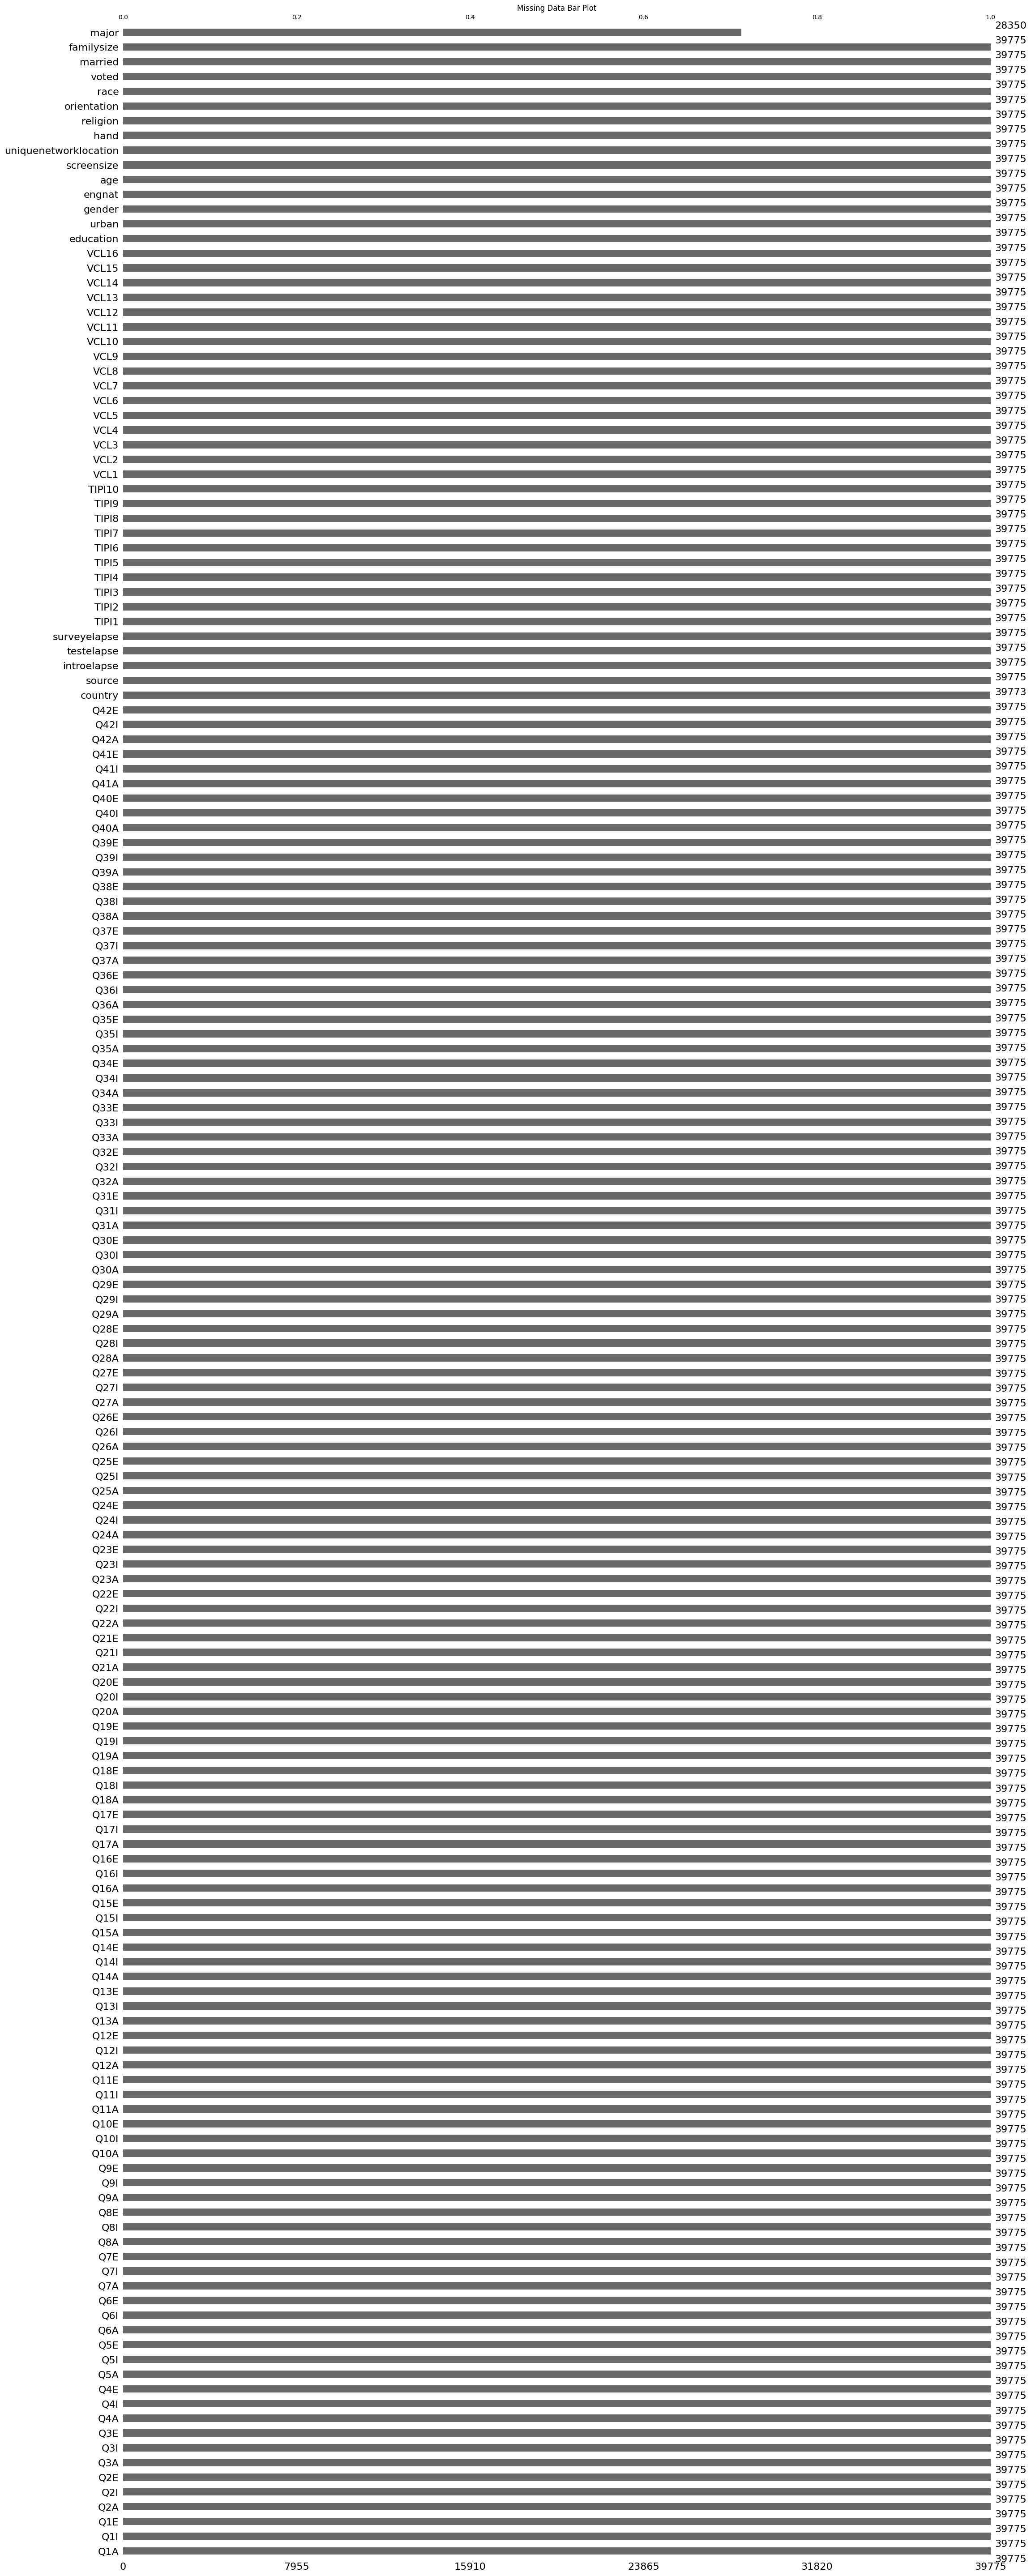

In [52]:
# Visual Method : menggunakan plot bar untuk melihat data hilang

# package msno function .bar(nama_dataframe)
msno.bar(df)

# Title untuk plot bar
plt.title('Missing Data Bar Plot')
# Menampilkan plot
plt.show()

In [53]:
# Check dataset row and columns before dropping null
print(f'This dataset has {df.shape[0]} rows and {df.shape[1]} columns')

This dataset has 39775 rows and 172 columns


In [54]:
# Drop baris yang memiliki nilai NULL lebih dari 5%
# HINT : gunakan function int(0.xx * len(df)) # sesuaikan untuk 5% (BUKAN 50%)
df = df.dropna(axis = 1, thresh = int(0.05 * len(df)))

In [55]:
# Major didrop karena memiliki data kosong yang sangat banyak.
# Drop Major
df = df.drop(['major'], axis = 1)
df.head()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize
0,4,28,3890,4,25,2122,2,16,1944,4,...,16,1,1,1,12,1,10,2,1,2
1,4,2,8118,1,36,2890,2,35,4777,3,...,16,2,1,2,7,0,70,2,1,4
2,3,7,5784,1,33,4373,4,41,3242,1,...,17,2,1,1,4,3,60,1,1,3
3,2,23,5081,3,11,6837,2,37,5521,1,...,13,2,1,2,4,5,70,2,1,5
4,2,36,3215,2,13,7731,3,5,4156,4,...,19,2,2,3,10,1,10,2,1,4


In [56]:
# Check dataset row and columns after dropping null values
print(f'This dataset has {df.shape[0]} rows and {df.shape[1]} columns')

This dataset has 39775 rows and 171 columns


In [57]:
# Cek Persentase data hilang lagi
# Descriptive Statistics : Hitung persentase keseluruhan

missing_data_all = df.isnull().stack().mean() * 100
print(f'All missing data percentage: {missing_data_all: .5f}%')


All missing data percentage:  0.00003%


In [58]:
# Mencari variable anomali

# terkadang ada data diluar scope, untuk skenario ini lihat codebook line 120-139
# disana terdapat kamus untuk setiap jawaban valid seperti gender
# pilihan gender hanya terdapat 1,2, dan 3

# lakukan pengecekan header dengan data yang tidak sesuai
# gunakan perintah nama_variabel = df['nama_header'].unique()

headers = ['education', 'urban', 'gender', 'engnat', 'age',
           'hand', 'religion', 'orientation', 'race', 'voted', 
           'married', 'familysize', 'country', 'screensize', 'uniquenetworklocation']


unique_values_dict = {} # Instansiasi array(?) unique_values_dict
# For loop memasukkan unique values masing-masing header ke dalam array unique_values_dict
for header in headers:
    if header in df.columns:
        unique_values = df[header].unique()
        unique_values_dict[header] = unique_values

# For loop ngeprint unique_values_dict
for header, values in unique_values_dict.items():
    print(f'{header}: {values}')


education: [2 1 3 4 0]
urban: [3 2 1 0]
gender: [2 1 3 0]
engnat: [2 1 0]
age: [  16   17   13   19   20   29   18   15   31   34   22   42   21   23
   26   43   35   25   24   61   40   27   28   60   14   37   46   57
   41   55   36   30   32   56   71   67   44   38   49   45   47   33
   54   53   50   48   58   68   39   51   62   59   52   77   85   63
   69   65   75   72   70   73   64   66   79   80   78  223 1996   89
  117   82   74 1998   76  115 1993 1991   99]
hand: [1 2 3 0]
religion: [12  7  4 10  2  6  1  8  3  0  5 11  9]
orientation: [1 0 3 5 2 4]
race: [10 70 60 50 30 40 20]
voted: [2 1 0]
married: [1 3 2 0]
familysize: [  2   4   3   5   1   6   8  12   7   0  11   9  13  10  62  16  14  99
  17  54  65  15  26  24  19  21  23 133]
country: ['IN' 'US' 'PL' 'MY' 'MX' 'GB' 'DE' 'EE' 'CA' 'EC' 'AU' 'FI' 'ID' 'AE'
 'NONE' 'ES' 'NI' 'DO' 'TR' 'NO' 'GR' 'LK' 'BR' 'AR' 'KH' 'IT' 'MK' 'PT'
 'BA' 'RU' 'HU' 'KR' 'IE' 'RS' 'CZ' 'PH' 'RO' 'FR' 'SG' 'AT' 'UA' 'KW'
 'CO' 'GE' 

<b>NOTES:</b>
- Incorrect values. The official DASS questionnare has values ranging from 0-3. not 1-4. The Dataset has incorrect values.

In [59]:
# Checking if VCL columns has outliers

vcl_columns = [f'VCL{i}' for i in range(1, 17)]

unique_values_dict = {} # Instansiasi array(?) unique_values_dict
# For loop memasukkan unique values masing-masing header ke dalam array unique_values_dict
for header in vcl_columns:
    if header in df.columns:
        unique_values = df[header].unique()
        unique_values_dict[header] = unique_values

# For loop ngeprint unique_values_dict
for header, values in unique_values_dict.items():
    print(f'{header}: {values}')

VCL1: [1 0]
VCL2: [0 1]
VCL3: [0 1]
VCL4: [1 0]
VCL5: [1 0]
VCL6: [0 1]
VCL7: [1 0]
VCL8: [0 1]
VCL9: [0 1]
VCL10: [1 0]
VCL11: [0 1]
VCL12: [0 1]
VCL13: [0 1]
VCL14: [1 0]
VCL15: [1 0]
VCL16: [1 0]


In [60]:
# Checking if TIPI columns has outliers

tipi_columns = [f'TIPI{i}' for i in range(1, 11)]

unique_values_dict = {} # Instansiasi array(?) unique_values_dict
# For loop memasukkan unique values masing-masing header ke dalam array unique_values_dict
for header in tipi_columns:
    if header in df.columns:
        unique_values = df[header].unique()
        unique_values_dict[header] = unique_values

# For loop ngeprint unique_values_dict
for header, values in unique_values_dict.items():
    print(f'{header}: {values}')

# Note:
# TIPI1 to TIPI10 has outlier. Codebook never mentioned the value 0 as an option, meaning it's an outlier.

TIPI1: [1 6 2 7 5 3 4 0]
TIPI2: [5 1 6 4 7 3 2 0]
TIPI3: [7 4 2 3 6 5 1 0]
TIPI4: [7 2 4 6 1 5 0 3]
TIPI5: [7 5 6 3 2 1 4 0]
TIPI6: [7 4 6 5 2 1 3 0]
TIPI7: [7 5 6 1 4 3 2 0]
TIPI8: [5 7 1 6 2 3 4 0]
TIPI9: [1 3 6 5 2 7 4 0]
TIPI10: [1 5 2 3 7 4 6 0]


In [61]:
# Checking if QxA columns has outliers

QxA_columns = [f'Q{i}A' for i in range(1, 43)]

unique_values_dict = {} # Instansiasi array(?) unique_values_dict
# For loop memasukkan unique values masing-masing header ke dalam array unique_values_dict
for header in QxA_columns:
    if header in df.columns:
        unique_values = df[header].unique()
        unique_values_dict[header] = unique_values

# For loop ngeprint unique_values_dict
for header, values in unique_values_dict.items():
    print(f'{header}: {values}')

# Note:
# TIPI1 to TIPI10 has outlier. Codebook never mentioned the value 0 as an option, meaning it's an outlier.

Q1A: [4 3 2 1]
Q2A: [4 1 3 2]
Q3A: [2 4 3 1]
Q4A: [4 3 1 2]
Q5A: [4 3 1 2]
Q6A: [4 3 2 1]
Q7A: [4 3 1 2]
Q8A: [4 3 2 1]
Q9A: [2 3 4 1]
Q10A: [1 2 4 3]
Q11A: [4 2 1 3]
Q12A: [4 2 1 3]
Q13A: [4 1 2 3]
Q14A: [4 1 3 2]
Q15A: [4 3 2 1]
Q16A: [4 3 2 1]
Q17A: [3 4 2 1]
Q18A: [4 2 1 3]
Q19A: [3 1 2 4]
Q20A: [3 1 2 4]
Q21A: [1 2 4 3]
Q22A: [4 3 1 2]
Q23A: [4 1 2 3]
Q24A: [4 2 1 3]
Q25A: [4 2 1 3]
Q26A: [4 3 1 2]
Q27A: [4 3 2 1]
Q28A: [3 4 1 2]
Q29A: [4 3 2 1]
Q30A: [2 3 4 1]
Q31A: [4 2 3 1]
Q32A: [4 3 1 2]
Q33A: [2 3 1 4]
Q34A: [3 2 4 1]
Q35A: [4 2 3 1]
Q36A: [4 3 1 2]
Q37A: [1 4 2 3]
Q38A: [2 4 1 3]
Q39A: [4 2 3 1]
Q40A: [3 1 2 4]
Q41A: [4 2 1 3]
Q42A: [4 2 3 1]


## Visualisasi Outlier

List Value Outlier: <br>
1. Education: 0
2. Urban: 0
3. Gender: 0
4. Engnat: 0
5. Age: Value more than 100
6. Hand: 0
7. Religion: 0
8. Orientation: 0
9. Voted: 0
10. Married: 0
11. Familysize: Value more than 20
12. Introelapse: Determined using IQR
13. Surveyelapse: Determined using IQR
14. Testelapse: Determined using IQR
15. TIPI1 to TIPI10: 0
16. Country: NULL VALUE NOT OUTLIER

In [62]:
# Convert introelapse, surveyelapse, testelapse from sec to mins
# df['introelapse'] = df['introelapse'] / 60
# df['surveyelapse'] = df['surveyelapse'] / 60
# df['testelapse'] = df['testelapse'] / 60    

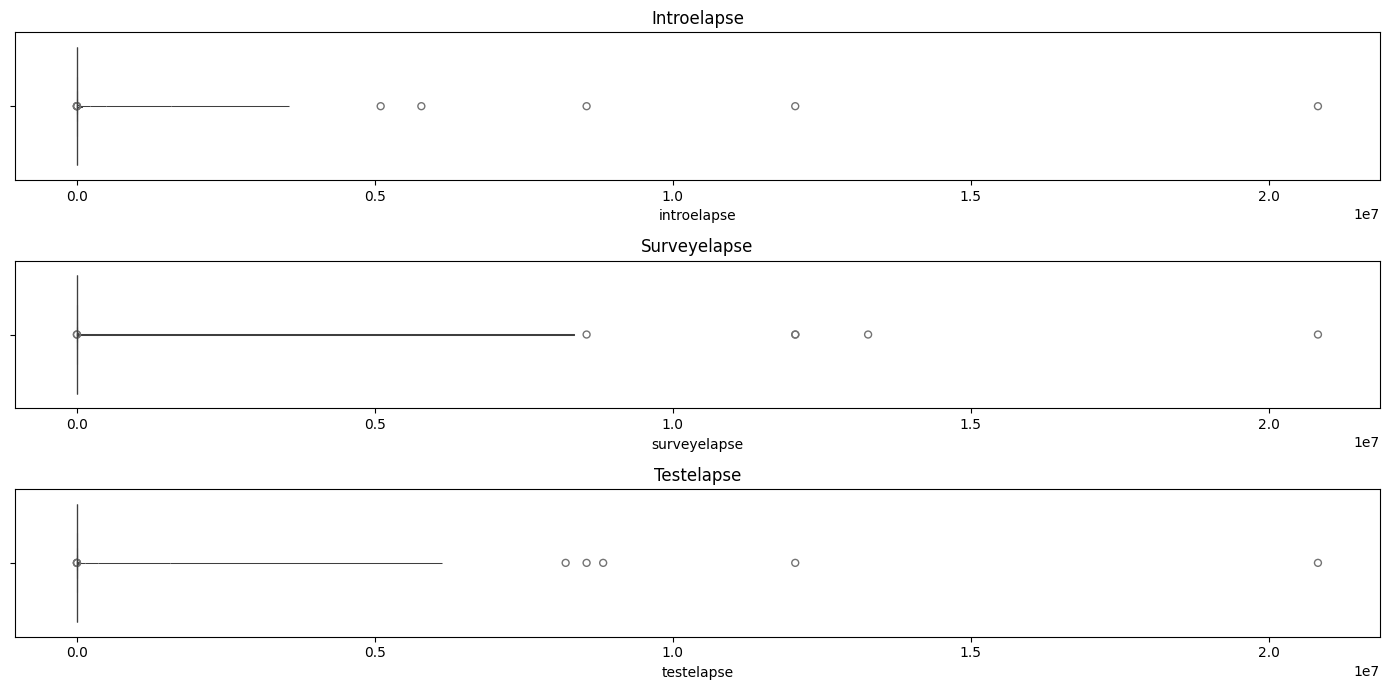

In [63]:
fig, axes = plt.subplots(3, figsize=(14, 7)) # kalau lebih dari satu plot, gunakan subplot | 3 = row subplot, 1 = column subplot

sns.boxenplot(data = df, x = df['introelapse'], ax=axes[0])
axes[0].set_title('Introelapse')

sns.boxenplot(data = df, x = df['surveyelapse'], ax=axes[1])
axes[1].set_title('Surveyelapse')

sns.boxenplot(data = df, x = df['testelapse'], ax=axes[2])
axes[2].set_title('Testelapse')

plt.tight_layout()
plt.show()

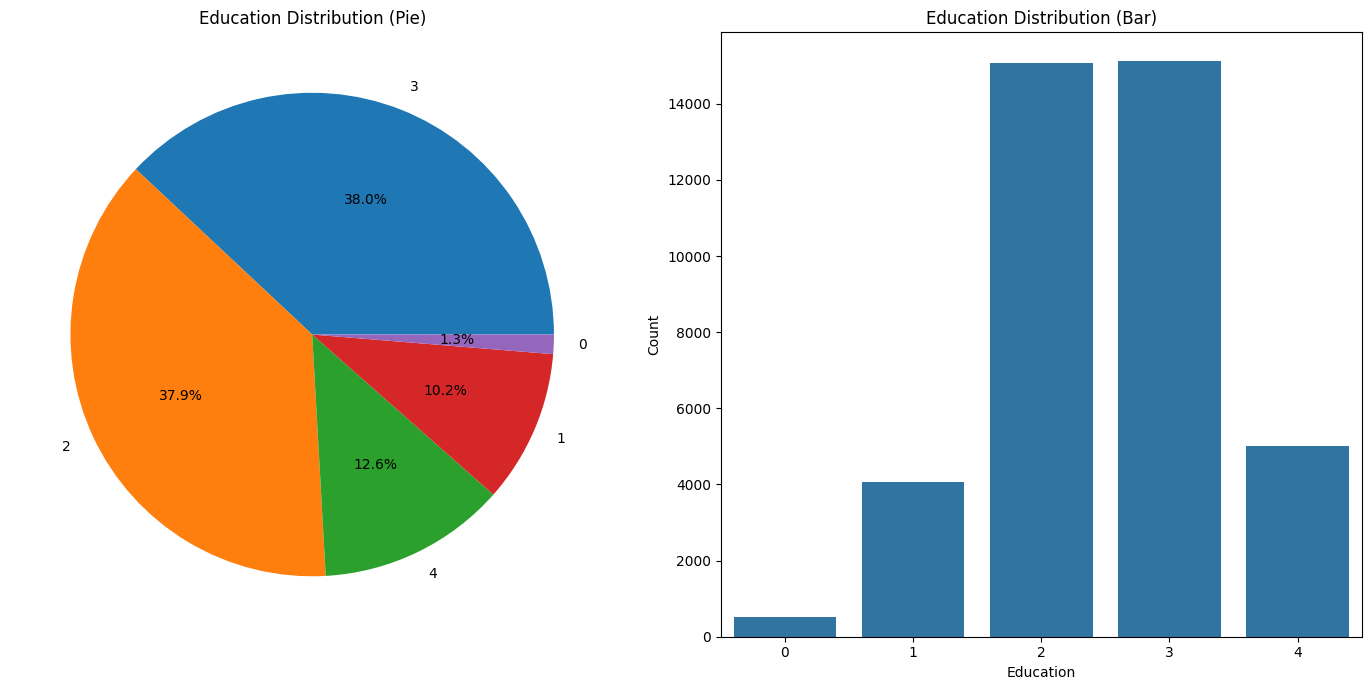

In [64]:
# Education
education_counts = df['education'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 7)) # kalau lebih dari satu plot, gunakan subplot | 1 = row subplot, 2 = column subplot

axes[0].pie(education_counts, labels=education_counts.index, autopct='%1.1f%%') # axis 0
axes[0].set_title('Education Distribution (Pie)')

sns.barplot(x=education_counts.index, y=education_counts.values, ax=axes[1]) # axis 1
axes[1].set_title('Education Distribution (Bar)')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

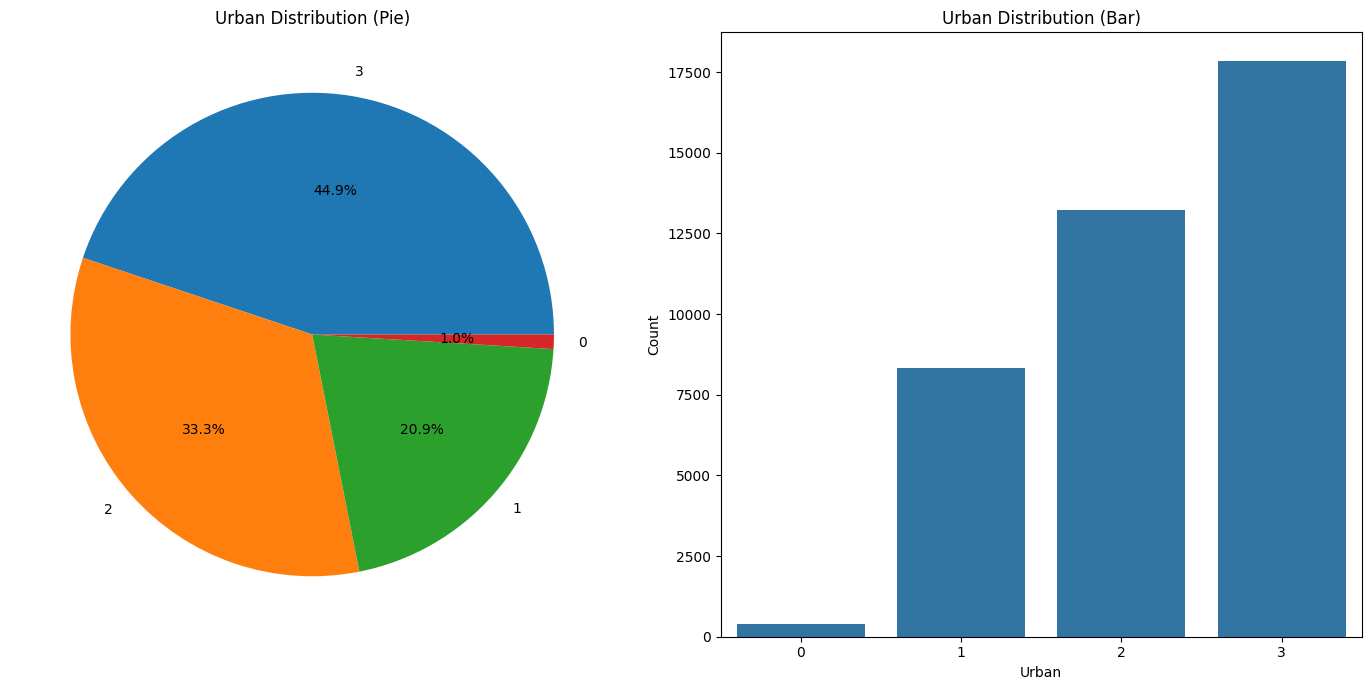

In [65]:
# Outlier Urban

urban_counts = df['urban'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 7)) # kalau lebih dari satu plot, gunakan subplot | 1 = row subplot, 2 = column subplot

axes[0].pie(urban_counts, labels=urban_counts.index, autopct='%1.1f%%') # axis 0
axes[0].set_title('Urban Distribution (Pie)')

sns.barplot(x=urban_counts.index, y=urban_counts.values, ax=axes[1]) # axis 1
axes[1].set_title('Urban Distribution (Bar)')
axes[1].set_xlabel('Urban')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

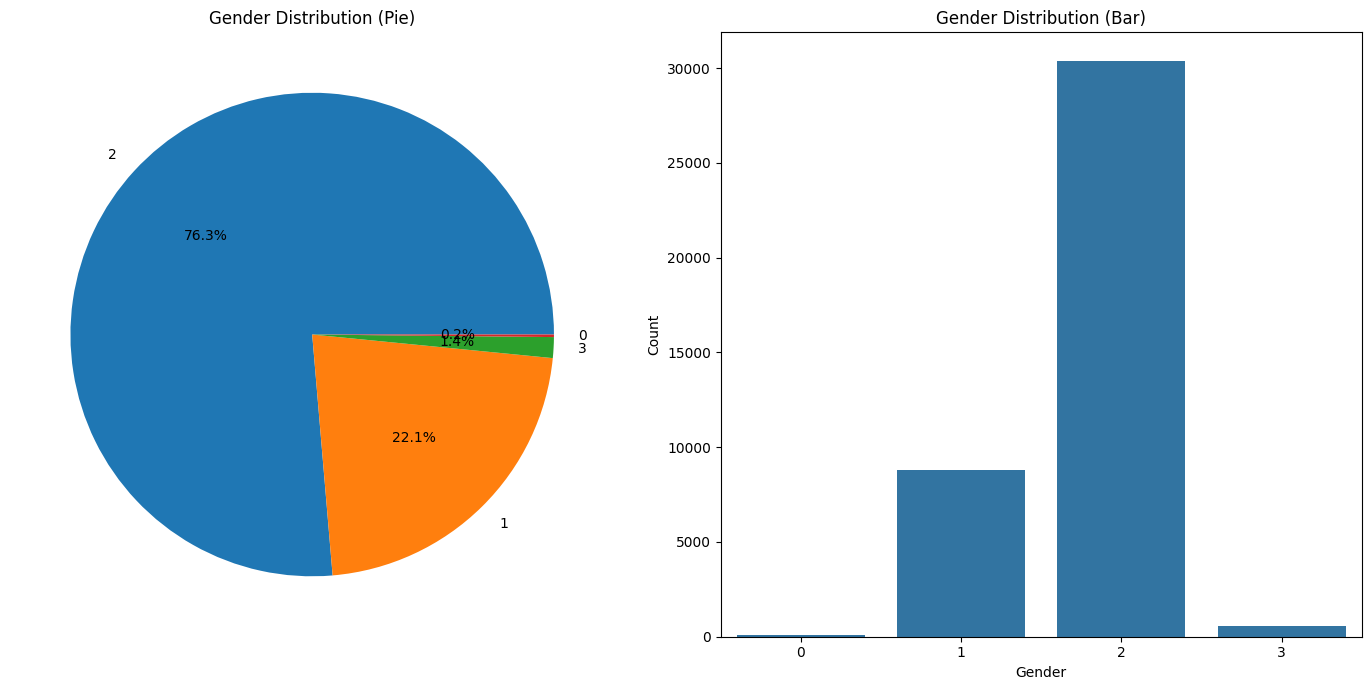

In [66]:
# Visualisasi Gender setelah imputasi outlier
gender_counts = df['gender'].value_counts()
# make var gender_counts lebih efisien

fig, axes = plt.subplots(1, 2, figsize=(14, 7)) # kalau lebih dari satu plot, gunakan subplot | 1 = row subplot, 2 = column subplot

axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%') # axis 0
axes[0].set_title('Gender Distribution (Pie)')

sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[1]) # axis 1
axes[1].set_title('Gender Distribution (Bar)')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

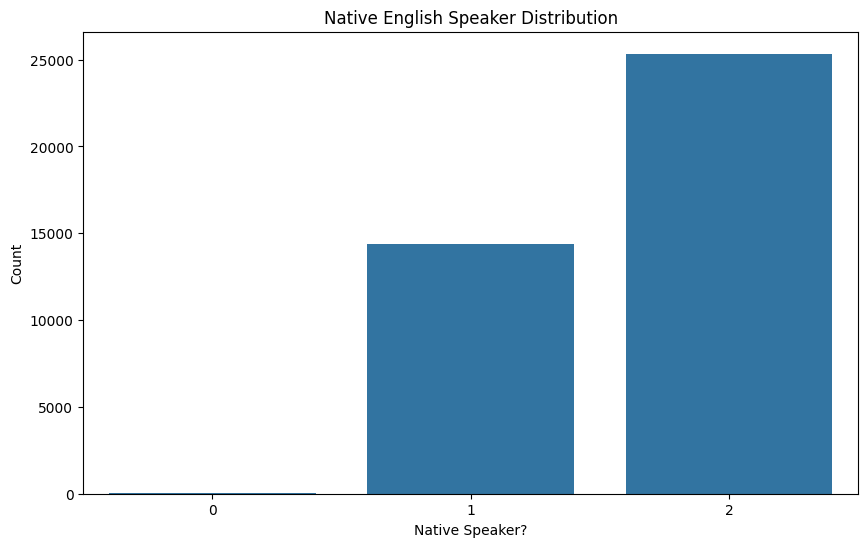

In [67]:
# Visualisasi engnat
engnat_counts = df['engnat'].value_counts()

plt.figure(figsize = (10, 6))
sns.barplot(x = engnat_counts.index, y = engnat_counts.values)
plt.title('Native English Speaker Distribution')
plt.xlabel('Native Speaker?')
plt.ylabel('Count')
plt.show()

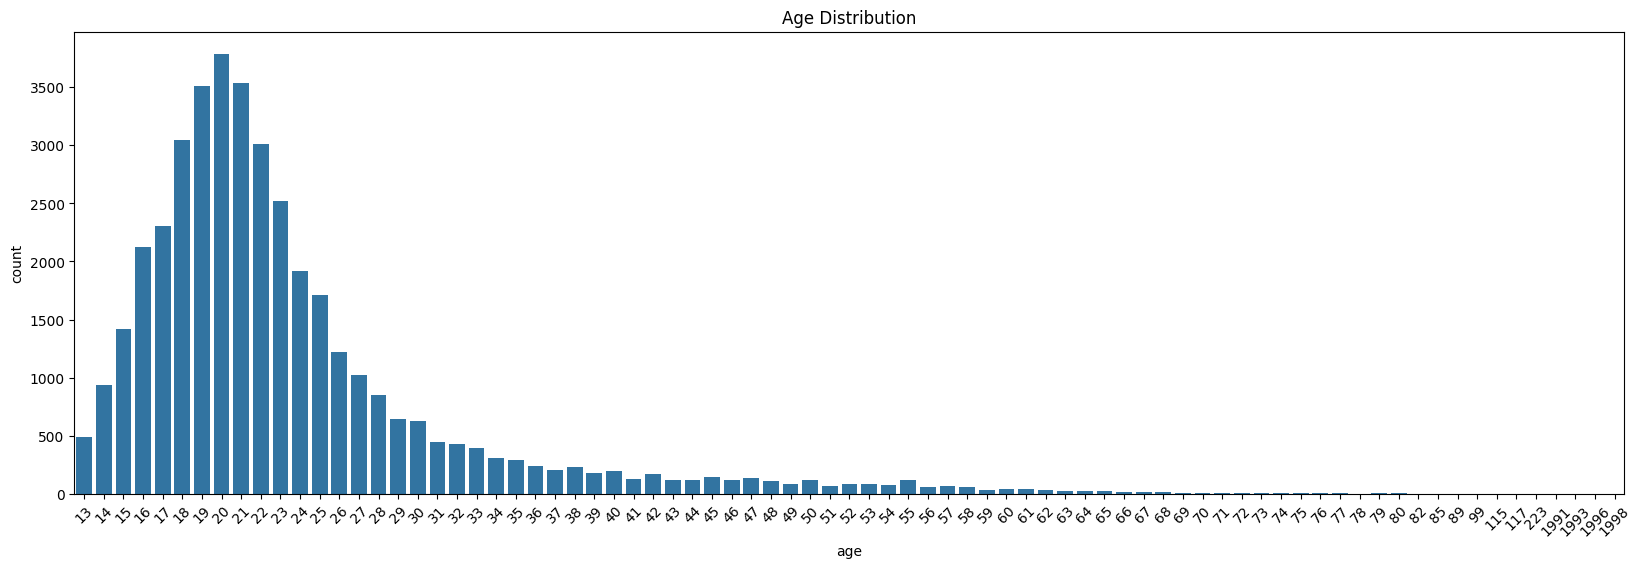

In [68]:
# Outlier Age

plt.figure(figsize = (20, 6))
sns.countplot(x = df['age'])
plt.title('Age Distribution')
plt.xticks(rotation = 45)
plt.show()

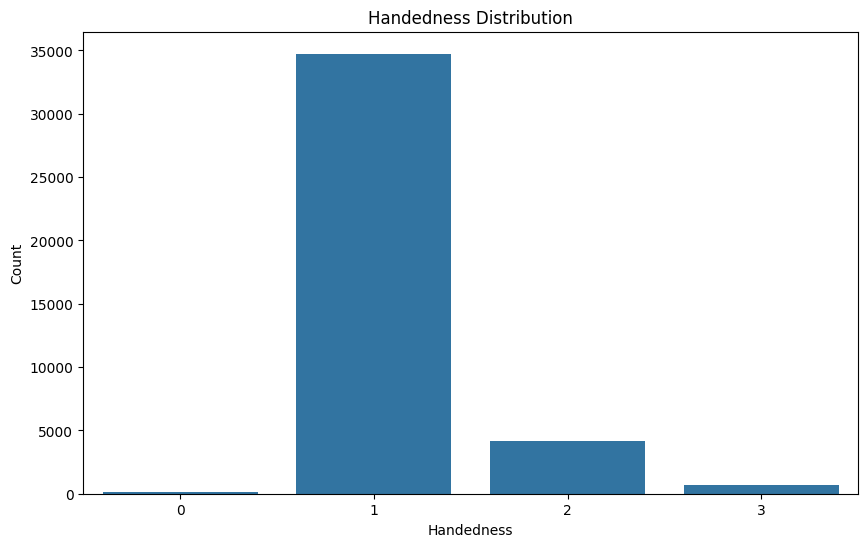

In [69]:
# Handedness outlier
hand_counts = df['hand'].value_counts()

plt.figure(figsize = (10, 6))
sns.barplot(x = hand_counts.index, y = hand_counts.values)
plt.title('Handedness Distribution')
plt.xlabel('Handedness')
plt.ylabel('Count')
plt.show()

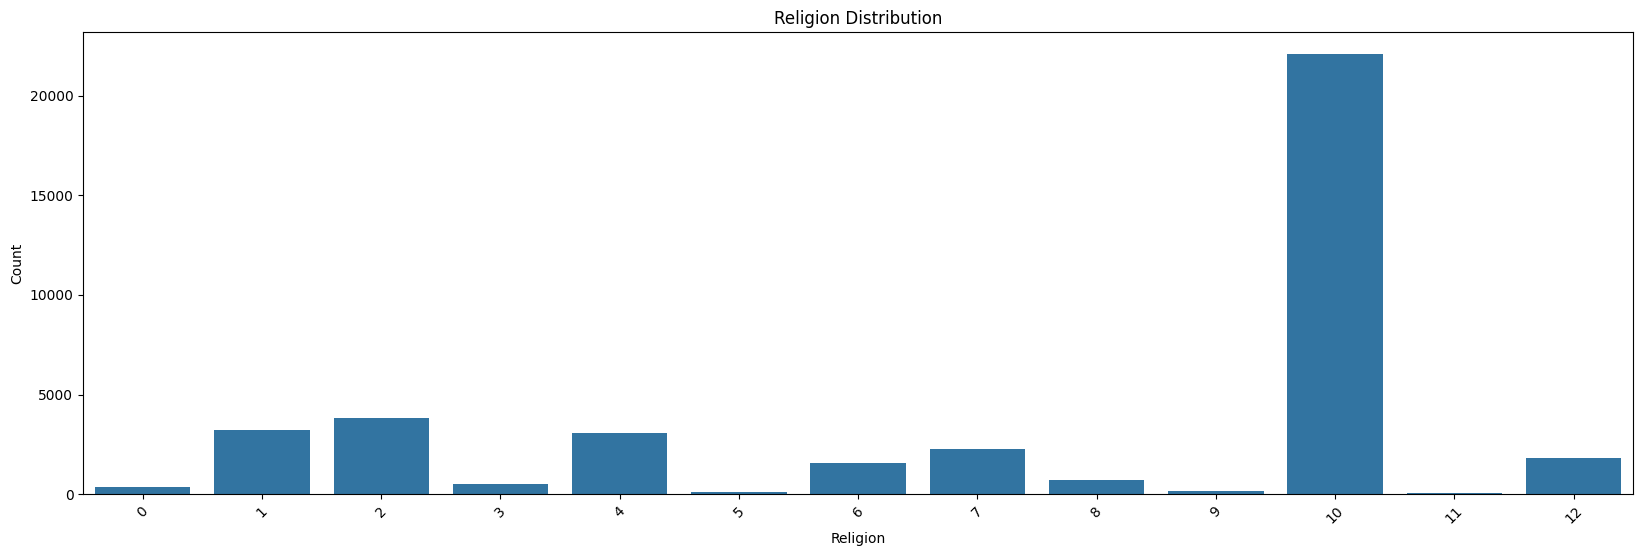

In [70]:
# Outlier Religion
religion_counts = df['religion'].value_counts()

plt.figure(figsize = (20, 6))
sns.barplot(x = religion_counts.index, y = religion_counts.values)
plt.title('Religion Distribution')
plt.xlabel('Religion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

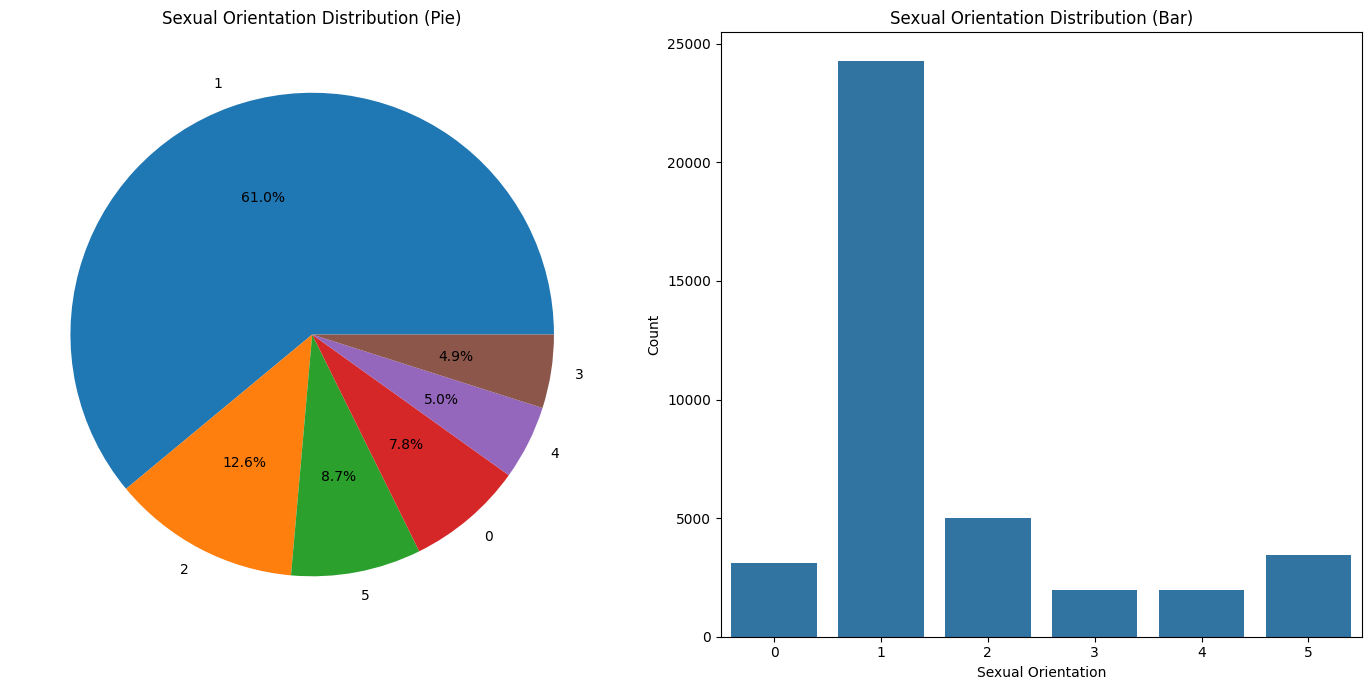

In [71]:
# Outlier Orientation
orientation_counts = df['orientation'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 7)) # kalau lebih dari satu plot, gunakan subplot | 1 = row subplot, 2 = column subplot

axes[0].pie(orientation_counts, labels=orientation_counts.index, autopct='%1.1f%%') # axis 0
axes[0].set_title('Sexual Orientation Distribution (Pie)')

sns.barplot(x=orientation_counts.index, y=orientation_counts.values, ax=axes[1]) # axis 1
axes[1].set_title('Sexual Orientation Distribution (Bar)')
axes[1].set_xlabel('Sexual Orientation')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

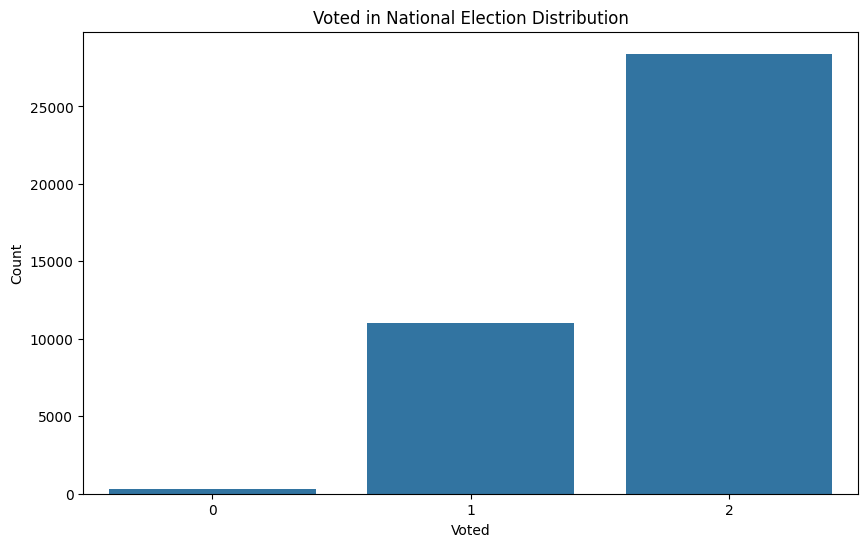

In [72]:
# Voted Outlier
voted_counts = df['voted'].value_counts()

plt.figure(figsize = (10, 6))
sns.barplot(x = voted_counts.index, y = voted_counts.values)
plt.title('Voted in National Election Distribution')
plt.xlabel('Voted')
plt.ylabel('Count')
plt.show()

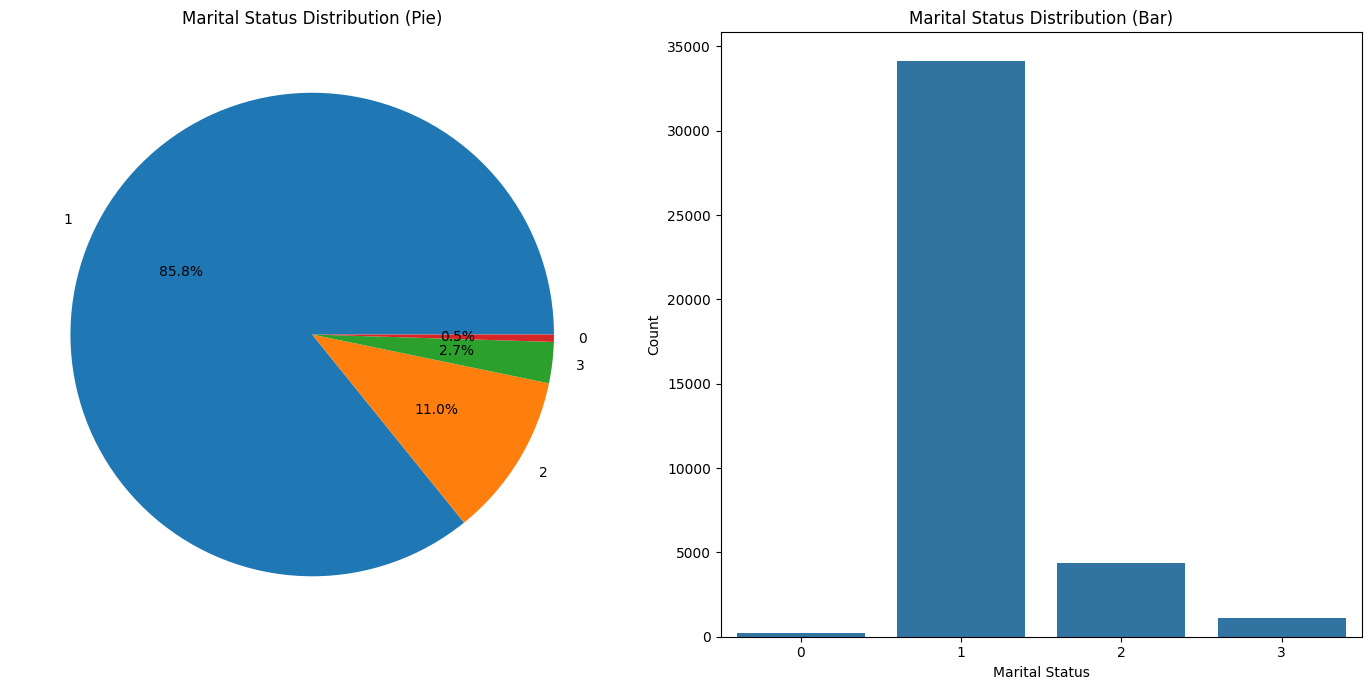

In [73]:
# Marriage Status Outlier

married_counts = df['married'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 7)) # kalau lebih dari satu plot, gunakan subplot | 1 = row subplot, 2 = column subplot

axes[0].pie(married_counts, labels=married_counts.index, autopct='%1.1f%%') # axis 0
axes[0].set_title('Marital Status Distribution (Pie)')

sns.barplot(x=married_counts.index, y=married_counts.values, ax=axes[1]) # axis 1
axes[1].set_title('Marital Status Distribution (Bar)')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

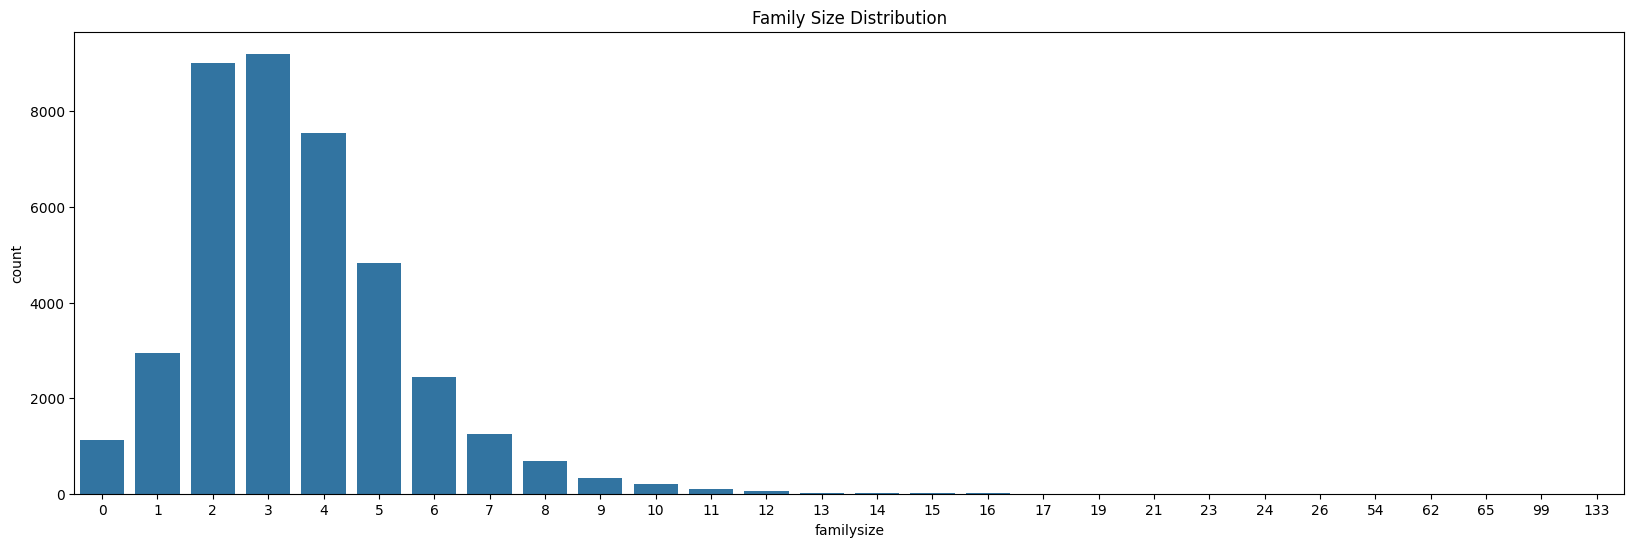

In [74]:
# Outlier Family Size

plt.figure(figsize = (20, 6))
sns.countplot(x = df['familysize'])
plt.title('Family Size Distribution')
plt.show()

In [75]:
# Demographic Dictionary
demo_dict = {
    'education':	    'How much education have you completed?',
    'urban':			'What type of area did you live when you were a child?',
    'gender':			'What is your gender?', 
    'engnat':			'Is English your native language?',
    'age':				'How many years old are you?',
    'hand':				'What hand do you use to write with?',
    'religion':			'What is your religion?',
    'orientation':		'What is your sexual orientation?',
    'race':				'What is your race?',
    'voted':			'Have you voted in a national election in the past year?',
    'married':			'What is your marital status?',
    'familysize':		'Including you, how many children did your mother have?'
}

In [76]:
df['race'] = df['race'].replace({10:1, 20:2, 30:3, 40:4, 50:5, 60:6, 70:7})

C:\Users\mfaiq\AppData\Local\Temp\ipykernel_23664\892731672.py:15: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_mapped['education'] = df_mapped['education'].replace(education_map)
C:\Users\mfaiq\AppData\Local\Temp\ipykernel_23664\892731672.py:16: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_mapped['urban'] = df_mapped['urban'].replace(urban_map)
C:\Users\mfaiq\AppData\Local\Temp\ipykernel_23664\892731672.py:17: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only b

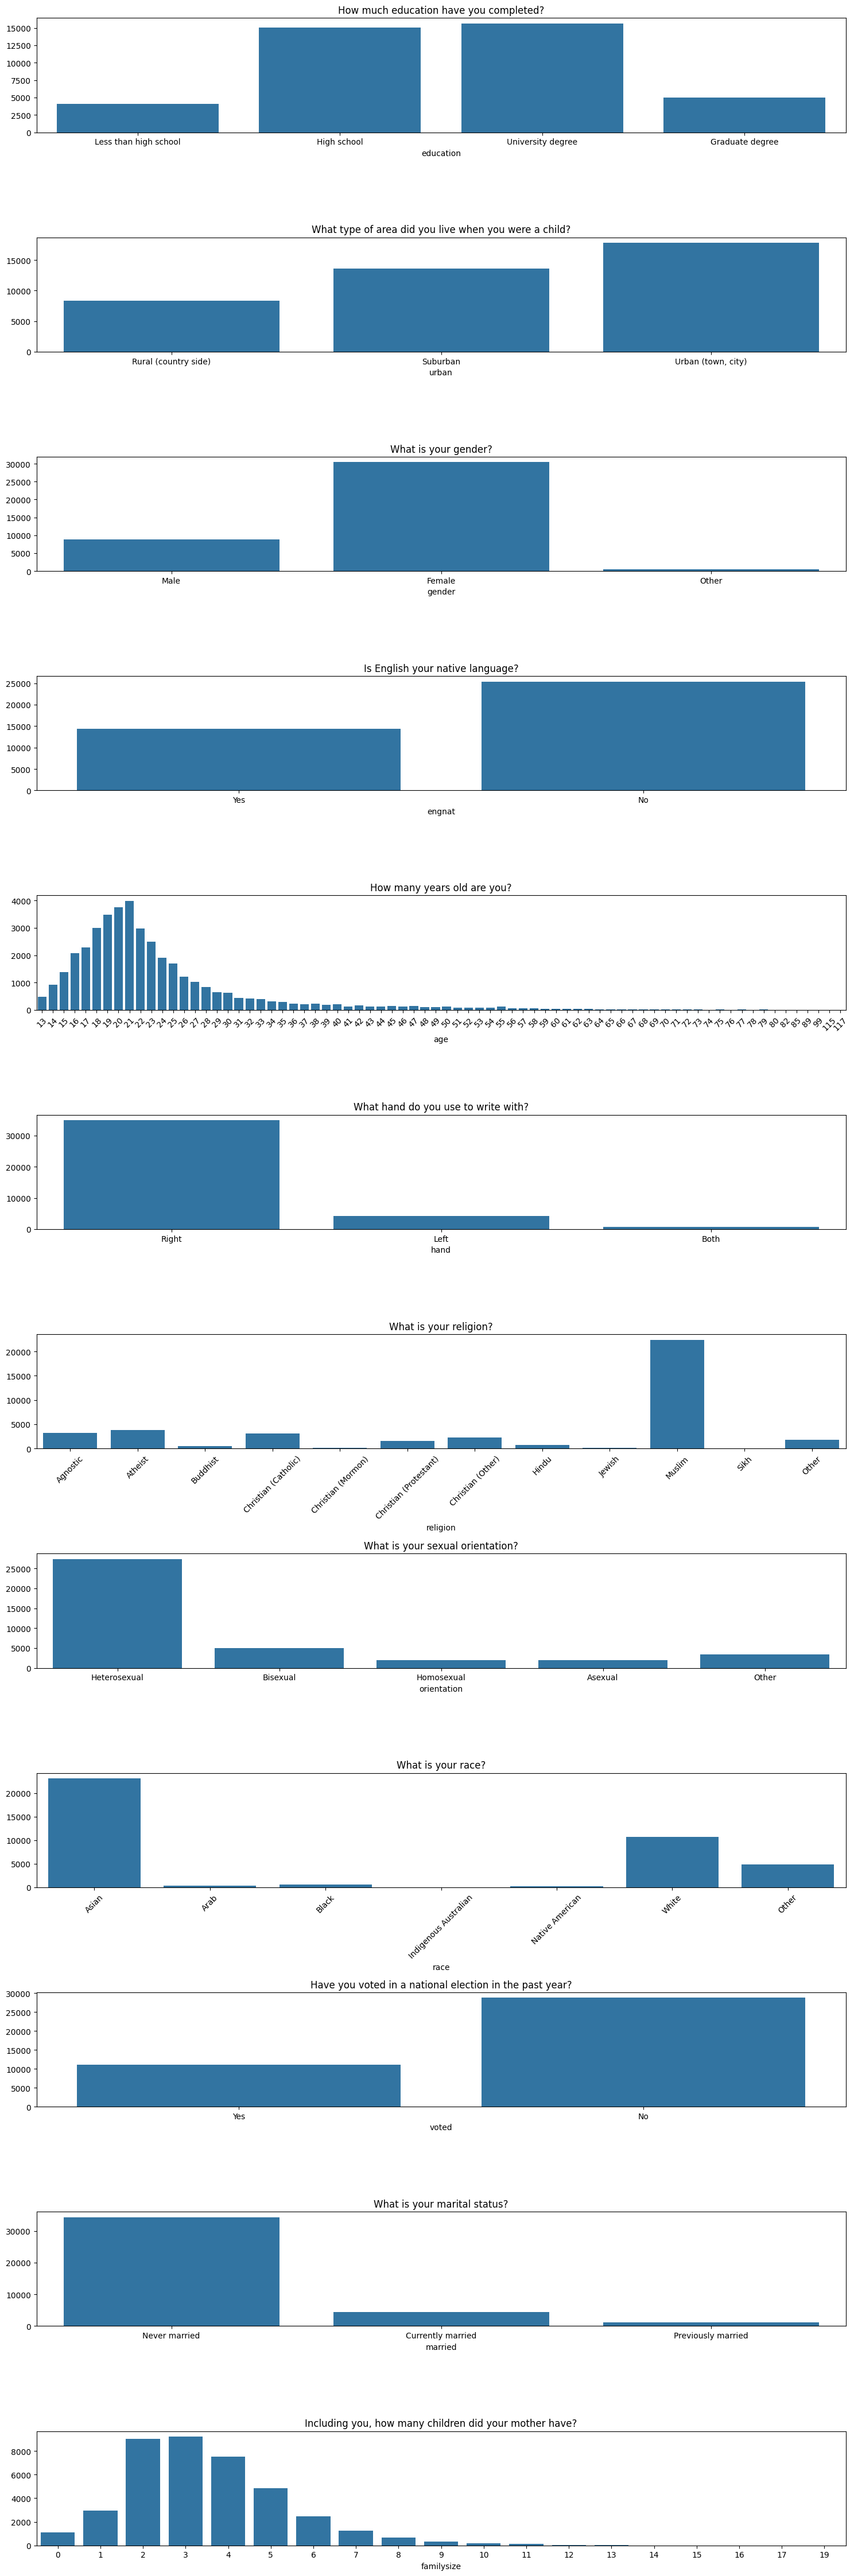

In [90]:
# Demographic mapping
education_map = {1: 'Less than high school', 2: 'High school', 3: 'University degree', 4: 'Graduate degree'}
urban_map = {1: 'Rural (country side)', 2: 'Suburban', 3: 'Urban (town, city)'}
gender_map = {1: 'Male', 2: 'Female', 3: 'Other'}
engnat_map = {1: 'Yes', 2: 'No'}
hand_map = {1: 'Right', 2: 'Left', 3: 'Both'}
religion_map = {1: 'Agnostic', 2: 'Atheist', 3: 'Buddhist', 4: 'Christian (Catholic)', 5: 'Christian (Mormon)', 6: 'Christian (Protestant)', 7: 'Christian (Other)', 8: 'Hindu', 9: 'Jewish', 10: 'Muslim', 11: 'Sikh', 12: 'Other'}
orientation_map = {1: 'Heterosexual', 2: 'Bisexual', 3: 'Homosexual', 4: 'Asexual', 5: 'Other'}
race_map = {1: 'Asian', 2: 'Arab', 3: 'Black', 4: 'Indigenous Australian', 5: 'Native American', 6: 'White', 7: 'Other'}
voted_map = {1: 'Yes', 2: 'No'}
married_map = {1: 'Never married', 2: 'Currently married', 3: 'Previously married'}

df_mapped = df.copy()

df_mapped['education'] = df_mapped['education'].replace(education_map)
df_mapped['urban'] = df_mapped['urban'].replace(urban_map)
df_mapped['gender'] = df_mapped['gender'].replace(gender_map)
df_mapped['engnat'] = df_mapped['engnat'].replace(engnat_map)
df_mapped['hand'] = df_mapped['hand'].replace(hand_map)
df_mapped['religion'] = df_mapped['religion'].replace(religion_map)
df_mapped['orientation'] = df_mapped['orientation'].replace(orientation_map)
df_mapped['race'] = df_mapped['race'].replace(race_map)
df_mapped['voted'] = df_mapped['voted'].replace(voted_map)
df_mapped['married'] = df_mapped['married'].replace(married_map)

# Demographic Features Visualization

# Subplots
fig, ax = plt.subplots(12, 1, figsize = (15,45)) # 12 Subplots for every demographic feature
fig.subplots_adjust(hspace=0.5) # Adjust spacing to avoid overlap

headers_visualized = ['education', 'urban', 'gender', 'engnat',
           'age', 'hand', 'religion', 'orientation',
           'race', 'voted', 'married', 'familysize']

for i, headers in enumerate(headers_visualized):
    header_counts = df_mapped[headers].value_counts()
    sns.barplot(x=header_counts.index, y=header_counts.values, ax=ax[i])
    ax[i].set_title(f'{demo_dict[headers]}')

    if headers == 'age' or headers == 'religion' or headers == 'race':
        ax[i].tick_params(axis='x', rotation=45)

fig.tight_layout() # Tighten Layout
plt.show()

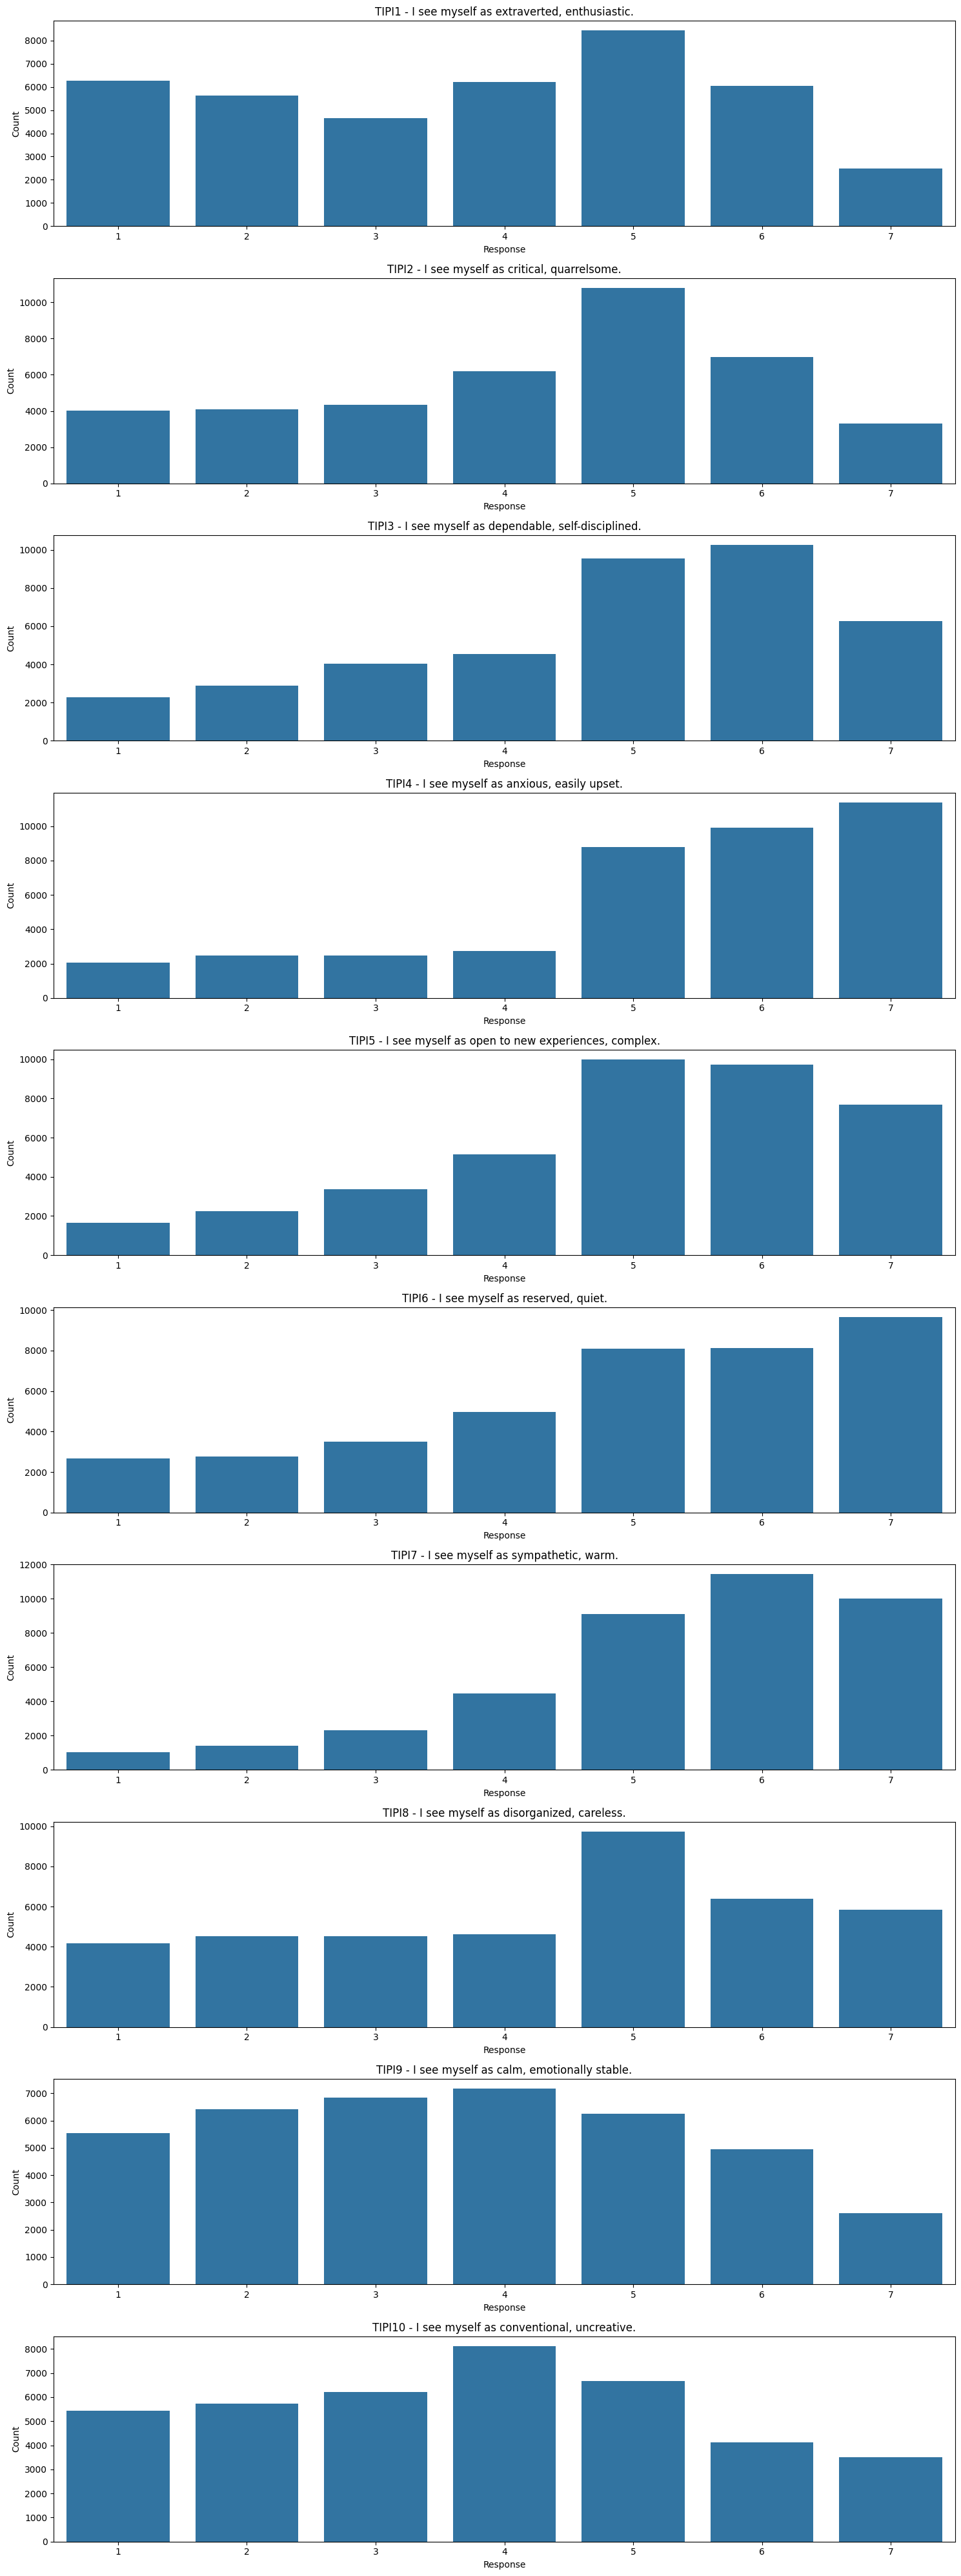

In [92]:
TIPI_map = {1: 'Strongly Disagree', 2: 'Disagree', 3: 'Slightly Disagree', 4: 'Neutral', 5: 'Slightly Agree', 6: 'Agree', 7: 'Strongly Agree'}
tipi_dict = {
    'TIPI1': 'I see myself as extraverted, enthusiastic.',
    'TIPI2': 'I see myself as critical, quarrelsome.',
    'TIPI3': 'I see myself as dependable, self-disciplined.',
    'TIPI4': 'I see myself as anxious, easily upset.',
    'TIPI5': 'I see myself as open to new experiences, complex.',
    'TIPI6': 'I see myself as reserved, quiet.',
    'TIPI7': 'I see myself as sympathetic, warm.',
    'TIPI8': 'I see myself as disorganized, careless.',
    'TIPI9': 'I see myself as calm, emotionally stable.',
    'TIPI10': 'I see myself as conventional, uncreative.'
}

# TIPI mapping for visualization
# for i in range(1, 11):
#     df_mapped[f'TIPI{i}'] = df_mapped[f'TIPI{i}'].replace(TIPI_map)

# TIPI Features Visualization
fig, ax = plt.subplots(10, 1, figsize = (15, 40)) # 10 Subplots for every TIPI feature
fig.subplots_adjust(hspace=0.5) # Adjust spacing to avoid overlap
for i in range(1, 11):
    tipi_counts = df[f'TIPI{i}'].value_counts().sort_index()
    sns.barplot(x=tipi_counts.index, y=tipi_counts.values, ax=ax[i-1])
    tipi_index = f'TIPI{i}'
    ax[i-1].set_title(f'TIPI{i} - {tipi_dict[tipi_index]}')
    ax[i-1].set_xlabel('Response')
    ax[i-1].set_ylabel('Count')

fig.tight_layout() # Tighten Layout
plt.show()

## Encoding Incorrect Questionnare Values

#### Convert Questionnare scores from 1-4 to 0-3.
Calculating DASS score values are based on the answers being 0-3 on the official DASS scoring guide. The dataset has them in 1-4 meaning the total scores will be incorrect.

In [79]:
# # Remapping values for DASS items
# # DASS (Depression, Anxiety, Stress Scales) items are typically scored from 0 to 3.
# # The scores doesn't calculate properly if the values do not start from 0. According to the official DASS scoring guidelines.
# # Remapping the values from 1-4 to 0-3 for each DASS item fixes this issue.

# # DASS Headers from Questions
# depression_items = ['Q3A', 'Q5A', 'Q10A', 'Q13A', 'Q16A', 'Q17A', 'Q21A', 'Q24A', 'Q26A', 'Q31A', 'Q34A', 'Q37A', 'Q38A', 'Q42A']
# anxiety_items = ['Q2A', 'Q4A', 'Q7A', 'Q9A', 'Q15A', 'Q19A', 'Q20A', 'Q23A', 'Q25A', 'Q28A', 'Q30A', 'Q36A', 'Q40A', 'Q41A']
# stress_items = ['Q1A', 'Q6A', 'Q8A', 'Q11A', 'Q12A', 'Q14A', 'Q18A', 'Q22A', 'Q27A', 'Q29A', 'Q32A', 'Q33A', 'Q35A', 'Q39A']
# dass_headers = depression_items + anxiety_items + stress_items

# # Remap or recode the DASS items
# for headers in dass_headers:
#     df[headers] = df[headers].replace({1: 0, 2: 1, 3: 2, 4: 3})

## Imputation and Encoding

Imputasi Outlier menggunakan median, mean, modus. <br>
<b>Mean</b> digunakan apabila persebaran data normal.<br>
<b>Median</b> digunakan apabila persebaran data tidak normal yang menyebabkan median dengan mean memiliki perbedaan jauh.<br>
<b>Modus</b> digunakan apabila data kategorikal.<br>

List Value Outlier: <br>
1. Education: 0 - Modus
2. Urban: 0 - Modus
3. Gender: 0 - Modus (Female), atau Other. Note: Imputing to 'Other' will make the data inaccurate for machine learning models.
4. Engnat: 0 - Modus
5. Age: Value lebih dari 80 - Median, difilter, atau liat dari header lain kemudian liat modusnya.
6. Hand: 0 - Modus
7. Religion: 0 - Modus (Muslim), atau Other. Note: Imputing to 'Other' will make the data inaccurate for machine learning models.
8. Orientation: 0 - Modus
9. Voted: 0 - Modus
10. Married: 0 - Modus
11. Familysize: Value lebih dari 10(?) - Median, difilter, atau liat dari header lain kemudian liat modusnya.
12. Introelapse: Median
13. Surveyelapse: Median
14. Testelapse: Median
15. Country: Mode - NOTE: Instead of outliers, it's null values being imputed with mode. Use groupby so the imputation takes into account other headers that are correlated

### Impute Time (Intro, Survey, Test)

### Imputing Age and Familysize

Age dan familysize casenya berbeda dari yang lain, dimana kasus lainnya dapat diimputasi menggunakan mode saja.

Age dan familysize memerlukan pertimbangan karena perlu diisi sesuai skew dari distribusi data.

Distribusi data kedua fitur tidak normal, maka perlu diterapkan berbagai hal, yaitu:
 - Membuat correlation heatmap. Berfungsi untuk mengetahui korelasi antar fitur. Digunakan untuk melakukan imputasi median atau mean yang melibatkan fitur lain yang berkorelasi. Imputasi melibatkan fitur yang berkorelasi lebih akurat daripada hanya melakukan imputasi fitur tersebut secara langsung.
 - Menerapkan pembatasan data yang logis. Contoh: umur di atas 100 tahun dan jumlah keluarga yang menyentuh angka belasan sangat langka dan mungkin tidak logis.


#### Correlation heatmap

##### Main Correlation Matrix

In [80]:
# Mencari variabel input yang berkorelasi tinggi dengan variabel output.
headers = ['education', 'urban', 'gender', 'engnat', 'age',
           'hand', 'religion', 'orientation', 'race', 'voted',
           'married', 'familysize']

# Input header correlation WITHOUT output header (DASS)
header_correlations = df[headers]

header_corr_matrix = header_correlations.corr()

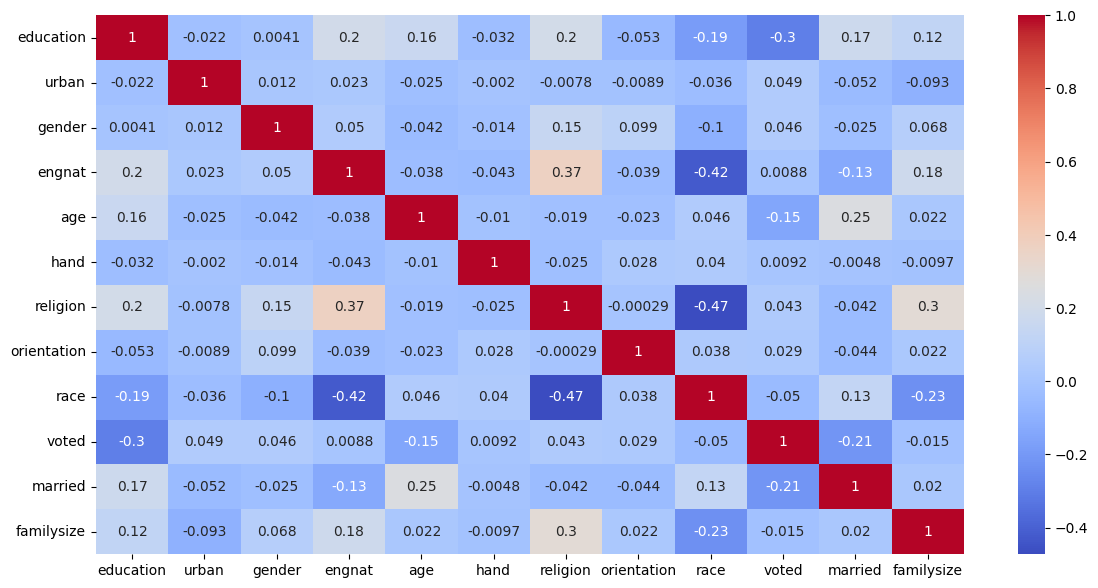

In [81]:
# Correlation heatmap
plt.figure(figsize=(14,7))
sns.heatmap(header_corr_matrix, annot=True, cmap='coolwarm')
plt.show()

#### Age Imputation

In [82]:
# # Set Logical Cap for Age
# logical_cap_age = 120

# # Set everything outside the logical cap as null value. Null value will be imputed later on.
# df['age'] = np.where(df['age'] > logical_cap_age, np.nan, df['age'])

# # Imputing Age using median of subgroups.
# # Deciding the subgroup used depends on what correlates with age
# # Age has correlations, including both positive and negative, towards education (+0.17), voted (-0.15), married (0.25)

# # Impute Age w/ based on median of subgroups.
# # TODO: Make notes explaining how lambda function works. Or decide on using other style of coding so it's 'readable' for others.
# df['age'] = df.groupby(by = ['education', 'voted', 'married'])['age'].transform(func = lambda x: x.fillna(x.median()))

# # In case there's still null values after imputing w/ subgroups.
# # Imputes null values with age's median without using subgroups.
# df['age'] = df['age'].fillna(df['age'].median()).astype('Int8')

# # Check if everything work as intended
# df['age'].describe()

In [83]:
# # Convert Data type from float to int
# # TODO: Converting data type doesn't work.
# df['age'] = df['age'].astype('Int8')
df['age'].describe()

count    39775.000000
mean        23.612168
std         21.581722
min         13.000000
25%         18.000000
50%         21.000000
75%         25.000000
max       1998.000000
Name: age, dtype: float64

#### Familysize Imputation

### Race Encoding

In [84]:
df['race'].head()

0    1
1    7
2    6
3    7
4    1
Name: race, dtype: int64

In [85]:
# Encode race to regular numbers

# Race uses 10, 20, 30, etc. instead of normal values#, such as 1, 2, 3.
# Encoding replaces those values to normal values to make them more consistent with the rest of the demographic features.

df['race'] = df['race'].replace({10:1, 20:2, 30:3, 40:4, 50:5, 60:6, 70:7})

In [86]:
# ----- Scales & columns -----
DASS_DEP = [3,5,10,13,16,17,21,24,26,31,34,37,38,42]
DASS_ANX = [2,4,7,9,15,19,20,23,25,28,30,36,40,41]
DASS_STR = [1,6,8,11,12,14,18,22,27,29,32,33,35,39]

DASS_A = [f'Q{i}A' for i in range(1,43)]
TIPI   = [f'TIPI{i}' for i in range(1,11)]
TIPI_REV = {2,4,6,8,10}  # reverse-keyed items

CAT_COLS = [
    'education','urban','gender','engnat','hand','religion','orientation',
    'race','voted','married','country','screensize','uniquenetworklocation','source'
]

DUR_COLS = ['introelapse','testelapse','surveyelapse']

# ----- Helpers -----
def _clean_raw(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Drop columns with >95% missing
    df = df.dropna(axis = 1, thresh = int(0.05 * len(df)))

    # Normalize empties
    for c in ['country','major']:
        if c in out.columns:
            out[c] = out[c].replace('', np.nan)

    # Replacing out of range answers or invalid answers with NaN. For example value 0 according to the codebook
    cat_answer_range = {
        'education' : (1, 4),
        'urban'     : (1, 3),
        'engnat'    : (1, 2),
        'hand'      : (1, 3),
        'voted'     : (1, 2),
        'orientation': (1, 5),
        'gender'    : (1, 3),
        'married'   : (1, 3),
        'religion'  : (1, 12),
    }
    for c, (lo, hi) in cat_answer_range.items():
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce')
            out.loc[(out[c] < lo) | (out[c] > hi), c] = np.nan

    for c in TIPI:
        out[c] = pd.to_numeric(out[c], errors='coerce')
        out.loc[(out[c] < 1) | (out[c] > 7), c] = np.nan

    # Age: impossible ages -> NaN
    if 'age' in out.columns:
        out['age'] = pd.to_numeric(out['age'], errors='coerce')
        out.loc[out['age'] > 120, 'age'] = np.nan

    # Family size: conservative plausible band
    if 'familysize' in out.columns:
        out['familysize'] = pd.to_numeric(out['familysize'], errors='coerce')
        out.loc[(out['familysize'] < 0) | (out['familysize'] > 20), 'familysize'] = np.nan

    # Durations: negatives -> NaN; drop top 1% as NaN
    # TODO: Winsorizing(?)
    for col in DUR_COLS:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
            out.loc[out[col] < 0, col] = np.nan
            q99 = out[col].quantile(0.99)
            out.loc[out[col] > q99, col] = np.nan

    # Per-item elapsed times Q?E
    dass_E = [c for c in out.columns if re.fullmatch(r'Q\d{1,2}E', c)]
    for col in dass_E:
        out[col] = pd.to_numeric(out[col], errors='coerce')
        out.loc[out[col] < 0, col] = np.nan
        q99 = out[col].quantile(0.99)
        out.loc[out[col] > q99, col] = np.nan

    return out

def impute_minimal(df: pd.DataFrame) -> pd.DataFrame:
    out = _clean_raw(df)

    # Numeric -> median
    num_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    for col in num_cols:
        # Specific age imputation
        if col == 'age':
            out[col] = out.groupby(
                by = ['education', 'voted', 'married'] # Group by columns correlated with age
            )['age'].transform(func = lambda x: x.fillna(x.median())) # Impute age based on median of subgroups
            out[col] = out[col].fillna(out[col].median())

        if out[col].isna().any():
            out[col] = out[col].fillna(out[col].median())

    # Convert familysize and age to int datatype from decimal
    for col in ['familysize', 'age']:
        out[col] = out[col].astype('Int16')

    # Categoricals -> most frequent
    for col in CAT_COLS:
        if col in out.columns:
            out[col] = out[col].astype('category')
            if out[col].isna().any():
                out[col] = out[col].fillna(out[col].mode(dropna=True)[0])

    # Free text 'major' -> 'Unknown'
    if 'major' in out.columns:
        out['major'] = out['major'].fillna('Unknown')

    return out

def impute_domain_guided(df: pd.DataFrame) -> pd.DataFrame:
    out = _clean_raw(df)

    # DASS: person-mean within subscale if <=20% missing; else item median
    for items in [DASS_DEP, DASS_ANX, DASS_STR]:
        cols = [f'Q{i}A' for i in items]
        sub = out[cols].copy()
        miss = sub.isna().sum(axis=1)
        row_mean = sub.mean(axis=1)
        # up to 20% missing within subscale
        allow = miss.le(int(np.floor(0.2 * len(cols))))
        for c in cols:
            need = allow & sub[c].isna()
            out.loc[need, c] = row_mean[need].round().clip(1,4).astype('Int8')

    # TIPI: replace missing from reverse-keyed pair when available
    pair = {1:6, 6:1, 7:2, 2:7, 3:8, 8:3, 9:4, 4:9, 5:10, 10:5}
    for i in range(1,11):
        c = f'TIPI{i}'
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce')

    for i, j in pair.items():
        ci, cj = f'TIPI{i}', f'TIPI{j}'
        if ci in out.columns and cj in out.columns:
            m = out[ci].isna() & out[cj].notna()
            # if either is reverse-keyed, impute with 8 - partner; else copy
            if (i in TIPI_REV) ^ (j in TIPI_REV):
                out.loc[m, ci] = 8 - out.loc[m, cj]
            else:
                out.loc[m, ci] = out.loc[m, cj]

    # Any remaining DASS/TIPI -> item median (keep ordinal)
    for c in DASS_A:
        if c in out.columns:
            out[c] = out[c].round().clip(1,4).astype('Int8')
            if out[c].isna().any():
                out[c] = out[c].fillna(out[c].median()).astype('Int8')

    for c in TIPI:
        if c in out.columns:
            out[c] = out[c].round().clip(1,7).astype('Int8')
            if out[c].isna().any():
                out[c] = out[c].fillna(out[c].median()).astype('Int8')

    # VCL binary -> mode
    vcl = [c for c in out.columns if re.fullmatch(r'VCL\d{1,2}', c)]
    for c in vcl:
        out[c] = pd.to_numeric(out[c], errors='coerce').clip(0,1)
        if out[c].isna().any():
            out[c] = out[c].fillna(out[c].mode(dropna=True)[0])

    # Demographics/durations as in Minimal
    out = impute_minimal(out)
    return out

In [87]:
df = impute_domain_guided(df)

In [88]:


# # Age: impossible ages -> NaN
# df['age'] = pd.to_numeric(df['age'], errors='coerce')
# df.loc[df['age'] > 120, 'age'] = np.nan
# df['age'] = df.groupby(by = ['education', 'voted', 'married'])['age'].transform(func = lambda x: x.fillna(x.median())) # Impute age based on median of subgroups
# df['age'] = df['age'].fillna(df['age'].median())

### Save Imputed Dataframe as CSV

In [89]:
# Convert dataframe to csv file
# df.to_csv('data_export_imputed05.csv', index=False) # index = False makes it so the index doesn't get treated as a Header when saved.

# Local Version Control
# 'data_export_imputed01.csv' is the first version of the imputed data.
# 'data_export_imputed02.csv'. Added race encoding.
# 'data_export_imputed03.csv'. Added TIPI imputation
# 'data_export_imputed04.csv'. Remapped QxA columns to 0-3. 
# 'data_export_imputed05.csv'. Changed imputation method on almost all columns.